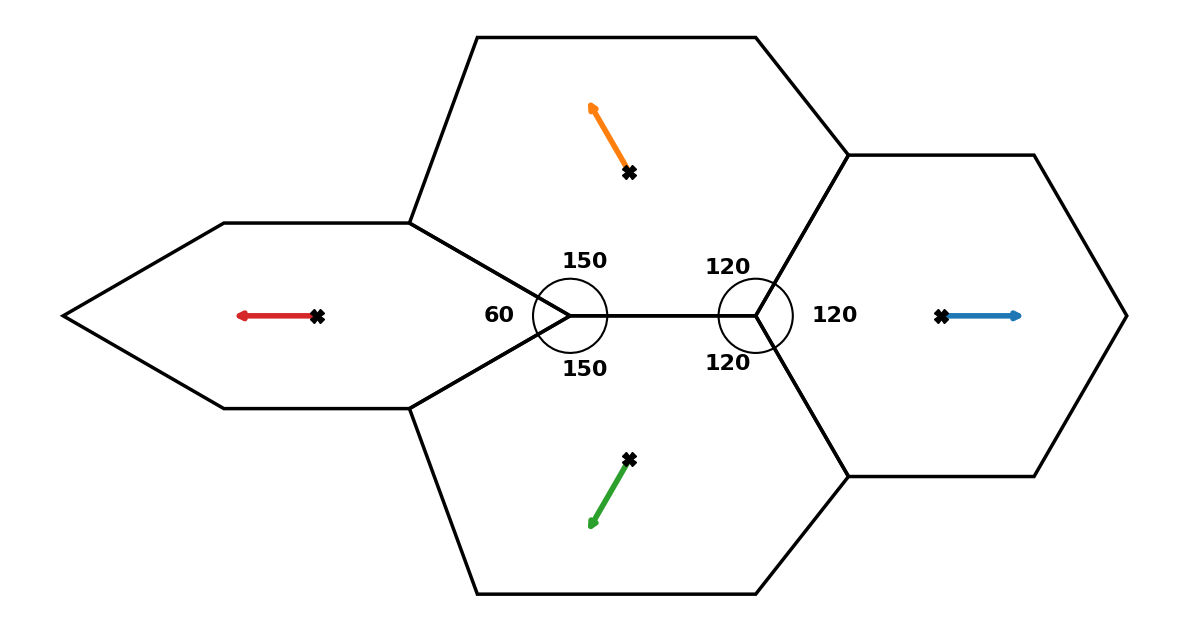

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Arc

# =====================================================================
# 1. Figure Setup
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Match the paper-like background color of the image
# bg_color = '#fdf6e3'
# fig.patch.set_facecolor(bg_color)
# ax.set_facecolor(bg_color)

# =====================================================================
# 2. Geometry Definition
# =====================================================================
v1 = (0.0, 0.0)
v2 = (1.0, 0.0)
v3 = (1.5, np.sqrt(3)/2)
v4 = (1.5, -np.sqrt(3)/2)
v5 = (-np.sqrt(3)/2, 0.5)
v6 = (-np.sqrt(3)/2, -0.5)

cells = {
    'R': [v2, v4, (2.5, -np.sqrt(3)/2), (3.0, 0.0), (2.5, np.sqrt(3)/2), v3],
    'T': [v1, v2, v3, (1.0, 1.5), (-0.5, 1.5), v5],
    'B': [v1, v6, (-0.5, -1.5), (1.0, -1.5), v4, v2],
    'L': [v1, v5, (-np.sqrt(3)/2 - 1, 0.5), (-np.sqrt(3) - 1, 0.0), (-np.sqrt(3)/2 - 1, -0.5), v6]
}

# Draw the cells
for name, verts in cells.items():
    poly = Polygon(verts, facecolor='none', edgecolor='black', linewidth=2.5, zorder=1)
    ax.add_patch(poly)

# =====================================================================
# 3. Angle Arcs and Text
# =====================================================================
# The width/height for Arc defines the diameter. A diameter of 0.4 means radius 0.2
arc_d = 0.4 
text_r = 0.3 # Distance from vertex to place the text

# --- Left Vertex (v1) ---
# Top-right 150
ax.add_patch(Arc(v1, arc_d, arc_d, theta1=0, theta2=150, edgecolor='black', lw=1.5))
ax.text(text_r * np.cos(np.deg2rad(75)), text_r * np.sin(np.deg2rad(75)), 
        '150', ha='center', va='center', fontsize=16, fontweight='bold')

# Bottom-right 150
ax.add_patch(Arc(v1, arc_d, arc_d, theta1=210, theta2=360, edgecolor='black', lw=1.5))
ax.text(text_r * np.cos(np.deg2rad(285)), text_r * np.sin(np.deg2rad(285)), 
        '150', ha='center', va='center', fontsize=16, fontweight='bold')

# Left 60
ax.add_patch(Arc(v1, arc_d, arc_d, theta1=150, theta2=210, edgecolor='black', lw=1.5))
ax.text(-text_r, 0, '60', ha='right', va='center', fontsize=16, fontweight='bold')


# --- Right Vertex (v2) ---
# Top-left 120
ax.add_patch(Arc(v2, arc_d, arc_d, theta1=60, theta2=180, edgecolor='black', lw=1.5))
ax.text(v2[0] + text_r * np.cos(np.deg2rad(120)), text_r * np.sin(np.deg2rad(120)), 
        '120', ha='center', va='center', fontsize=16, fontweight='bold')

# Bottom-left 120
ax.add_patch(Arc(v2, arc_d, arc_d, theta1=180, theta2=300, edgecolor='black', lw=1.5))
ax.text(v2[0] + text_r * np.cos(np.deg2rad(240)), text_r * np.sin(np.deg2rad(240)), 
        '120', ha='center', va='center', fontsize=16, fontweight='bold')

# Right 120
ax.add_patch(Arc(v2, arc_d, arc_d, theta1=300, theta2=420, edgecolor='black', lw=1.5))
ax.text(v2[0] + text_r, 0, '120', ha='left', va='center', fontsize=16, fontweight='bold')


# =====================================================================
# 4. Reflecting Arrows (Non-expansive mode)
# =====================================================================
def get_centroid(verts):
    x = np.array([v[0] for v in verts])
    y = np.array([v[1] for v in verts])
    cross = x * np.roll(y, -1) - y * np.roll(x, -1)
    area = 0.5 * np.sum(cross)
    cx = np.sum((x + np.roll(x, -1)) * cross) / (6 * area)
    cy = np.sum((y + np.roll(y, -1)) * cross) / (6 * area)
    return np.array([cx, cy])

# Arrow magnitude
mag = 0.45

# Shift vectors for the mathematically reflecting set
shifts = {
    'R': np.array([mag, 0.0]),                                    # Right
    'L': np.array([-mag, 0.0]),                                   # Left
    'T': np.array([-mag * np.cos(np.pi/3), mag * np.sin(np.pi/3)]), # Up-Left (120 deg)
    'B': np.array([-mag * np.cos(np.pi/3), -mag * np.sin(np.pi/3)]) # Down-Left (240 deg)
}

colors = {
    'R': 'tab:blue', 
    'L': 'tab:red', 
    'T': 'tab:orange', 
    'B': 'tab:green'
}

for name, verts in cells.items():
    c = get_centroid(verts)
    s = shifts[name]
    
    # Mark the centroid
    ax.plot(c[0], c[1], marker='X', color='black', markersize=10, zorder=3)
    
    # Draw the reflecting arrow
    ax.annotate('', xy=c + s, xytext=c,
                arrowprops=dict(arrowstyle='->', color=colors[name], lw=4.0, shrinkA=0, shrinkB=0),
                zorder=2)

# =====================================================================
# 5. Final Formatting
# =====================================================================
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

# export the figure as a high-resolution PNG
fig.savefig('sketch.png', dpi=600, bbox_inches='tight')

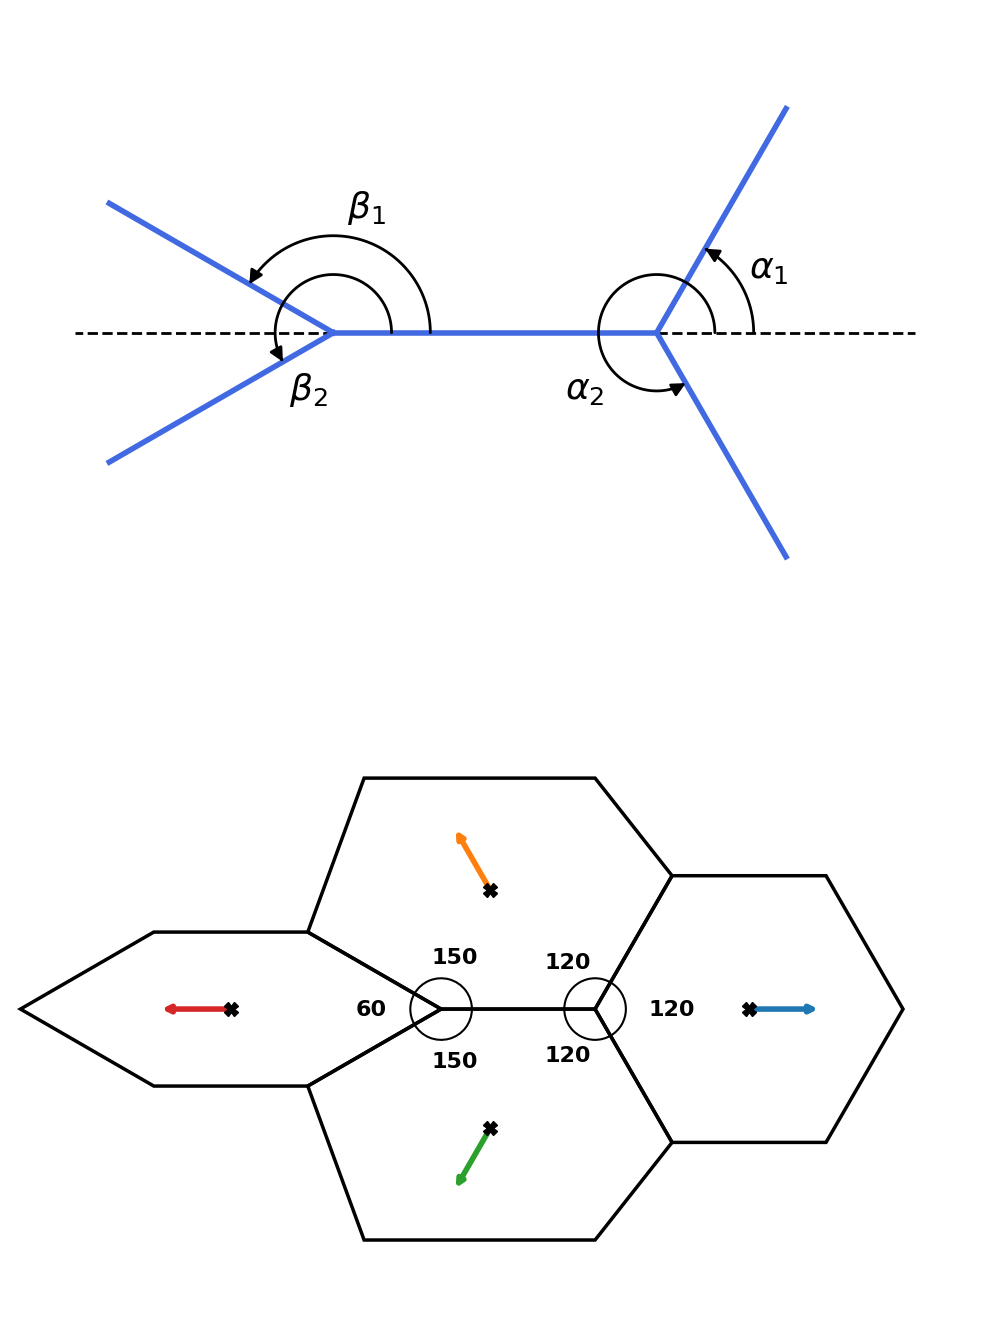

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Arc
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# =====================================================================
# 1. Figure Setup
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

# Ensure background is pure white
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# =====================================================================
# 2. Top Subplot: Angle Definition Diagram
# =====================================================================
# Draw the thick blue lines
blue_color = 'royalblue'
line_lw = 4

# Center segment
ax1.plot([0, 1], [0, 0], color=blue_color, lw=line_lw, zorder=2)

# Left branches (150 degrees and 210 degrees)
L = 0.8
ax1.plot([0, L * np.cos(np.deg2rad(150))], [0, L * np.sin(np.deg2rad(150))], color=blue_color, lw=line_lw, zorder=2)
ax1.plot([0, L * np.cos(np.deg2rad(210))], [0, L * np.sin(np.deg2rad(210))], color=blue_color, lw=line_lw, zorder=2)

# Right branches (60 degrees and 300 degrees)
ax1.plot([1, 1 + L * np.cos(np.deg2rad(60))], [0, L * np.sin(np.deg2rad(60))], color=blue_color, lw=line_lw, zorder=2)
ax1.plot([1, 1 + L * np.cos(np.deg2rad(300))], [0, L * np.sin(np.deg2rad(300))], color=blue_color, lw=line_lw, zorder=2)

# Dashed line extending to the right
ax1.plot([1, 1 + L], [0, 0], color='black', linestyle='--', lw=2, zorder=1)

# Dashed line extending to the left (for clarity of the horizontal axis)
ax1.plot([0, -L], [0, 0], color='black', linestyle='--', lw=2, zorder=1)

# Helper function to draw an arc with an arrowhead at the end
def add_arc_arrow(ax, center, radius, theta1, theta2, color='black', lw=2):
    t = np.linspace(np.deg2rad(theta1), np.deg2rad(theta2), 100)
    x = center[0] + radius * np.cos(t)
    y = center[1] + radius * np.sin(t)
    verts = np.column_stack([x, y])
    codes = [mpath.Path.MOVETO] + [mpath.Path.LINETO] * (len(verts) - 1)
    path = mpath.Path(verts, codes)
    patch = mpatches.FancyArrowPatch(path=path, color=color, lw=lw,
                                     arrowstyle='-|>', mutation_scale=20, zorder=3)
    ax.add_patch(patch)

# Draw arcs with arrows (ALL measured Counter-Clockwise from 0 degrees)
# Alpha 2 and Beta 2 get a smaller radius so they nest inside Alpha 1 and Beta 1
r_inner = 0.18
r_outer = 0.30

add_arc_arrow(ax1, (0, 0), r_outer, 0, 150)       # Beta 1 (0 to 150 CCW)
add_arc_arrow(ax1, (0, 0), r_inner, 0, 210)       # Beta 2 (0 to 210 CCW)
add_arc_arrow(ax1, (1, 0), r_outer, 0, 60)        # Alpha 1 (0 to 60 CCW)
add_arc_arrow(ax1, (1, 0), r_inner, 0, 300)       # Alpha 2 (0 to 300 CCW)

# Add LaTeX text labels (Positioned neatly outside the arc limits/arrowheads)
ax1.text(0.40 * np.cos(np.deg2rad(75)), 0.40 * np.sin(np.deg2rad(75)), r'$\beta_1$', ha='center', va='center', fontsize=26)
ax1.text(0.1 + 0.25 * np.cos(np.deg2rad(225)), 0.25 * np.sin(np.deg2rad(225)), r'$\beta_2$', ha='center', va='center', fontsize=26)
ax1.text(1.0 + 0.40 * np.cos(np.deg2rad(30)), 0.40 * np.sin(np.deg2rad(30)), r'$\alpha_1$', ha='center', va='center', fontsize=26)
ax1.text(0.6 + 0.25 * np.cos(np.deg2rad(315)), 0.25 * np.sin(np.deg2rad(315)), r'$\alpha_2$', ha='center', va='center', fontsize=26)

ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_xlim(-1.0, 2.0)
ax1.set_ylim(-0.8, 1.0)

# =====================================================================
# 3. Bottom Subplot: Geometric Layout & Shifts
# =====================================================================
v1 = (0.0, 0.0)
v2 = (1.0, 0.0)
v3 = (1.5, np.sqrt(3)/2)
v4 = (1.5, -np.sqrt(3)/2)
v5 = (-np.sqrt(3)/2, 0.5)
v6 = (-np.sqrt(3)/2, -0.5)

cells = {
    'R': [v2, v4, (2.5, -np.sqrt(3)/2), (3.0, 0.0), (2.5, np.sqrt(3)/2), v3],
    'T': [v1, v2, v3, (1.0, 1.5), (-0.5, 1.5), v5],
    'B': [v1, v6, (-0.5, -1.5), (1.0, -1.5), v4, v2],
    'L': [v1, v5, (-np.sqrt(3)/2 - 1, 0.5), (-np.sqrt(3) - 1, 0.0), (-np.sqrt(3)/2 - 1, -0.5), v6]
}

# Draw the cells
for name, verts in cells.items():
    poly = Polygon(verts, facecolor='none', edgecolor='black', linewidth=2.5, zorder=1)
    ax2.add_patch(poly)

# --- Angle Arcs and Text ---
arc_d = 0.4 
text_r = 0.35 

# Left Vertex (v1)
ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=0, theta2=150, edgecolor='black', lw=1.5))
ax2.text(text_r * np.cos(np.deg2rad(75)), text_r * np.sin(np.deg2rad(75)), '150', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=210, theta2=360, edgecolor='black', lw=1.5))
ax2.text(text_r * np.cos(np.deg2rad(285)), text_r * np.sin(np.deg2rad(285)), '150', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=150, theta2=210, edgecolor='black', lw=1.5))
ax2.text(-text_r, 0, '60', ha='right', va='center', fontsize=16, fontweight='bold')

# Right Vertex (v2)
ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=60, theta2=180, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r * np.cos(np.deg2rad(120)), text_r * np.sin(np.deg2rad(120)), '120', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=180, theta2=300, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r * np.cos(np.deg2rad(240)), text_r * np.sin(np.deg2rad(240)), '120', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=300, theta2=420, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r, 0, '120', ha='left', va='center', fontsize=16, fontweight='bold')

# --- Reflecting Arrows ---
def get_centroid(verts):
    x = np.array([v[0] for v in verts])
    y = np.array([v[1] for v in verts])
    cross = x * np.roll(y, -1) - y * np.roll(x, -1)
    area = 0.5 * np.sum(cross)
    cx = np.sum((x + np.roll(x, -1)) * cross) / (6 * area)
    cy = np.sum((y + np.roll(y, -1)) * cross) / (6 * area)
    return np.array([cx, cy])

mag = 0.45
shifts = {
    'R': np.array([mag, 0.0]),                                   
    'L': np.array([-mag, 0.0]),                                   
    'T': np.array([-mag * np.cos(np.pi/3), mag * np.sin(np.pi/3)]), 
    'B': np.array([-mag * np.cos(np.pi/3), -mag * np.sin(np.pi/3)]) 
}

colors = {'R': 'tab:blue', 'L': 'tab:red', 'T': 'tab:orange', 'B': 'tab:green'}

for name, verts in cells.items():
    c = get_centroid(verts)
    s = shifts[name]
    
    ax2.plot(c[0], c[1], marker='X', color='black', markersize=10, zorder=3)
    ax2.annotate('', xy=c + s, xytext=c,
                 arrowprops=dict(arrowstyle='->', color=colors[name], lw=4.0, shrinkA=0, shrinkB=0),
                 zorder=2)

ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_xlim(-2.8, 3.5)
ax2.set_ylim(-2.0, 1.6)

plt.tight_layout()
plt.show()

# export the figure as a high-resolution PNG
fig.savefig('sketch.png', dpi=600, bbox_inches='tight')

# Side by side

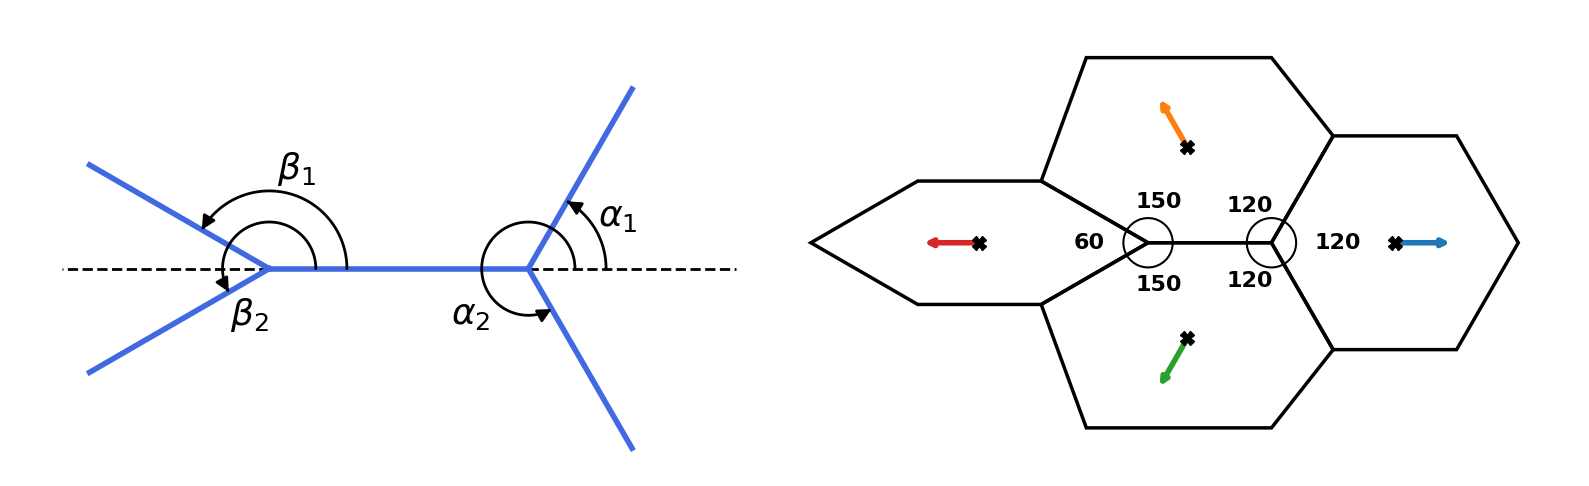

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Arc
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# =====================================================================
# 1. Figure Setup
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

# Ensure background is pure white
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# =====================================================================
# 2. Top Subplot: Angle Definition Diagram
# =====================================================================
# Draw the thick blue lines
blue_color = 'royalblue'
line_lw = 4

# Center segment
ax1.plot([0, 1], [0, 0], color=blue_color, lw=line_lw, zorder=2)

# Left branches (150 degrees and 210 degrees)
L = 0.8
ax1.plot([0, L * np.cos(np.deg2rad(150))], [0, L * np.sin(np.deg2rad(150))], color=blue_color, lw=line_lw, zorder=2)
ax1.plot([0, L * np.cos(np.deg2rad(210))], [0, L * np.sin(np.deg2rad(210))], color=blue_color, lw=line_lw, zorder=2)

# Right branches (60 degrees and 300 degrees)
ax1.plot([1, 1 + L * np.cos(np.deg2rad(60))], [0, L * np.sin(np.deg2rad(60))], color=blue_color, lw=line_lw, zorder=2)
ax1.plot([1, 1 + L * np.cos(np.deg2rad(300))], [0, L * np.sin(np.deg2rad(300))], color=blue_color, lw=line_lw, zorder=2)

# Dashed line extending to the right
ax1.plot([1, 1 + L], [0, 0], color='black', linestyle='--', lw=2, zorder=1)

# Dashed line extending to the left (for clarity of the horizontal axis)
ax1.plot([0, -L], [0, 0], color='black', linestyle='--', lw=2, zorder=1)

# Helper function to draw an arc with an arrowhead at the end
def add_arc_arrow(ax, center, radius, theta1, theta2, color='black', lw=2):
    t = np.linspace(np.deg2rad(theta1), np.deg2rad(theta2), 100)
    x = center[0] + radius * np.cos(t)
    y = center[1] + radius * np.sin(t)
    verts = np.column_stack([x, y])
    codes = [mpath.Path.MOVETO] + [mpath.Path.LINETO] * (len(verts) - 1)
    path = mpath.Path(verts, codes)
    patch = mpatches.FancyArrowPatch(path=path, color=color, lw=lw,
                                     arrowstyle='-|>', mutation_scale=20, zorder=3)
    ax.add_patch(patch)

# Draw arcs with arrows (ALL measured Counter-Clockwise from 0 degrees)
# Alpha 2 and Beta 2 get a smaller radius so they nest inside Alpha 1 and Beta 1
r_inner = 0.18
r_outer = 0.30

add_arc_arrow(ax1, (0, 0), r_outer, 0, 150)       # Beta 1 (0 to 150 CCW)
add_arc_arrow(ax1, (0, 0), r_inner, 0, 210)       # Beta 2 (0 to 210 CCW)
add_arc_arrow(ax1, (1, 0), r_outer, 0, 60)        # Alpha 1 (0 to 60 CCW)
add_arc_arrow(ax1, (1, 0), r_inner, 0, 300)       # Alpha 2 (0 to 300 CCW)

# Add LaTeX text labels (Positioned neatly outside the arc limits/arrowheads)
ax1.text(0.40 * np.cos(np.deg2rad(75)), 0.40 * np.sin(np.deg2rad(75)), r'$\beta_1$', ha='center', va='center', fontsize=26)
ax1.text(0.1 + 0.25 * np.cos(np.deg2rad(225)), 0.25 * np.sin(np.deg2rad(225)), r'$\beta_2$', ha='center', va='center', fontsize=26)
ax1.text(1.0 + 0.40 * np.cos(np.deg2rad(30)), 0.40 * np.sin(np.deg2rad(30)), r'$\alpha_1$', ha='center', va='center', fontsize=26)
ax1.text(0.6 + 0.25 * np.cos(np.deg2rad(315)), 0.25 * np.sin(np.deg2rad(315)), r'$\alpha_2$', ha='center', va='center', fontsize=26)

ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_xlim(-1.0, 2.0)
ax1.set_ylim(-0.8, 1.0)

# =====================================================================
# 3. Bottom Subplot: Geometric Layout & Shifts
# =====================================================================
v1 = (0.0, 0.0)
v2 = (1.0, 0.0)
v3 = (1.5, np.sqrt(3)/2)
v4 = (1.5, -np.sqrt(3)/2)
v5 = (-np.sqrt(3)/2, 0.5)
v6 = (-np.sqrt(3)/2, -0.5)

cells = {
    'R': [v2, v4, (2.5, -np.sqrt(3)/2), (3.0, 0.0), (2.5, np.sqrt(3)/2), v3],
    'T': [v1, v2, v3, (1.0, 1.5), (-0.5, 1.5), v5],
    'B': [v1, v6, (-0.5, -1.5), (1.0, -1.5), v4, v2],
    'L': [v1, v5, (-np.sqrt(3)/2 - 1, 0.5), (-np.sqrt(3) - 1, 0.0), (-np.sqrt(3)/2 - 1, -0.5), v6]
}

# Draw the cells
for name, verts in cells.items():
    poly = Polygon(verts, facecolor='none', edgecolor='black', linewidth=2.5, zorder=1)
    ax2.add_patch(poly)

# --- Angle Arcs and Text ---
arc_d = 0.4 
text_r = 0.35 

# Left Vertex (v1)
ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=0, theta2=150, edgecolor='black', lw=1.5))
ax2.text(text_r * np.cos(np.deg2rad(75)), text_r * np.sin(np.deg2rad(75)), '150', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=210, theta2=360, edgecolor='black', lw=1.5))
ax2.text(text_r * np.cos(np.deg2rad(285)), text_r * np.sin(np.deg2rad(285)), '150', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v1, arc_d, arc_d, theta1=150, theta2=210, edgecolor='black', lw=1.5))
ax2.text(-text_r, 0, '60', ha='right', va='center', fontsize=16, fontweight='bold')

# Right Vertex (v2)
ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=60, theta2=180, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r * np.cos(np.deg2rad(120)), text_r * np.sin(np.deg2rad(120)), '120', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=180, theta2=300, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r * np.cos(np.deg2rad(240)), text_r * np.sin(np.deg2rad(240)), '120', ha='center', va='center', fontsize=16, fontweight='bold')

ax2.add_patch(Arc(v2, arc_d, arc_d, theta1=300, theta2=420, edgecolor='black', lw=1.5))
ax2.text(v2[0] + text_r, 0, '120', ha='left', va='center', fontsize=16, fontweight='bold')

# --- Reflecting Arrows ---
def get_centroid(verts):
    x = np.array([v[0] for v in verts])
    y = np.array([v[1] for v in verts])
    cross = x * np.roll(y, -1) - y * np.roll(x, -1)
    area = 0.5 * np.sum(cross)
    cx = np.sum((x + np.roll(x, -1)) * cross) / (6 * area)
    cy = np.sum((y + np.roll(y, -1)) * cross) / (6 * area)
    return np.array([cx, cy])

mag = 0.45
shifts = {
    'R': np.array([mag, 0.0]),                                   
    'L': np.array([-mag, 0.0]),                                   
    'T': np.array([-mag * np.cos(np.pi/3), mag * np.sin(np.pi/3)]), 
    'B': np.array([-mag * np.cos(np.pi/3), -mag * np.sin(np.pi/3)]) 
}

colors = {'R': 'tab:blue', 'L': 'tab:red', 'T': 'tab:orange', 'B': 'tab:green'}

for name, verts in cells.items():
    c = get_centroid(verts)
    s = shifts[name]
    
    ax2.plot(c[0], c[1], marker='X', color='black', markersize=10, zorder=3)
    ax2.annotate('', xy=c + s, xytext=c,
                 arrowprops=dict(arrowstyle='->', color=colors[name], lw=4.0, shrinkA=0, shrinkB=0),
                 zorder=2)

ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_xlim(-2.8, 3.5)
ax2.set_ylim(-1.6, 1.6)

plt.tight_layout()
plt.show()

# export the figure as a high-resolution PNG
fig.savefig('sketch.png', dpi=600, bbox_inches='tight')